# Object Detection

Object detection = What objects are present + where are they /


A computer needs something precise so we draw a bounding box around the object.

The four numbers of bounding box:

```
(x_min, y_min, x_max, y_max)
```
Image in coordinate system:

```

(0,0)
  ┌──────────────────────→ x
  │
  │
  │       ┌─────────┐
  │       │  object │
  │       └─────────┘
  │
  ↓
  y


so:

- X_min = left edge
- y_min = top edge
- x_max= right edge
- y_max = bottom edge

eg
(100, 50, 300, 250)

````

> The object starts around (100,50) and ends around (300,250).

## Object detection produces more than box:

```

Object #1
    Class: dog
    Confidence: 0.94
    Box: [100, 50, 300, 250]

Object #2
    Class: person
    Confidence: 0.89
    Box: [400, 40, 500, 300]


so conceptually:

Detection
   │
   ├── What? → class
   │
   ├── Where? → bounding box
   │
   └── How sure? → confidence


```

* Class tells us what the object is:


```
Car
person
dog
```

if model detects these things:

```

[car]
[dog]
[person]

These are object classes.

```

* What is confidence ?

The model isnt always 100% sure.


```
0.99 → very confident
0.90 → pretty confident
0.50 → uncertain
0.10 → very unlikely
```

so we apply confidence threshold:

for example
```
confidence > 0.5
```

which only keep predictions above 50%.

For each detected object:

```
┌────────────────────────────┐
│                            │
│   WHAT?                    │
│   → Class                  │
│                            │
│   WHERE?                   │
│   → Bounding box           │
│                            │
│   HOW SURE?                │
│   → Confidence score       │
│                            │
└────────────────────────────┘
```

Object detection in nutshell.


## Fine Tuning:

> Take a model that has already learned something useful and train it a little more for specific task.

Imagine

```
Pretrained model
       ↓
Already knows general vision
       ↓
Fine-tune
       ↓
Your specific task
```



| Pretraining | Fine-tuning |
| --- | --- |
| Learn general features | Learn task-specific features |
| Usually huge dataset | Usually smaller dataset |
| Expensive | Cheaper |
| Takes a long time | Usually much faster |
| General model | Specialized model |


## What are changed during fine tuning ?


A neural network  contains lots of learned number called weights.

During training:


```
Input
 ↓
Neural network
 ↓
Prediction
 ↓
Compare with correct answer
 ↓
Calculate error
 ↓
Update weights
 ↓
Repeat
```

The weights are essentially the models learned knowledge.

Fine Tuning means:

> Adjust some or all of those learned weights so the model becomes better at our particular task.

<br>

### what is our dataset going to look like ?

Object detection datasets are different from normal image classification datasets.

For classification:

```

image.jpg
     ↓
cat


For object detection:

image.jpg
     ↓
dog
box: [100, 50, 300, 250]

person
box: [400, 20, 500, 300]

One image can have many objects.

That's a crucial difference.

```

> Classification gives the cateogory

> Detection gives category + location

<br>

---
Object detection answers "WHAT is in the image and WHERE is it?", and instead of teaching a neural network everything from zero, we usually start with a pretrained model and fine-tune it for our specific objects.

In [ ]:
# installing necessary libraries

!pip install -U -q datasets transformers[torch] evaluate timm albumentations accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.7 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

dataset=load_dataset("anindya64/hardhat")
dataset

README.md:   0%|          | 0.00/872 [00:00<?, ?B/s]

data/train-00000-of-00001-3e0d95da2811af(…): reconstructing file:   0%|          |  0.00B /  200MB            

data/train-00000-of-00001-3e0d95da2811af(…): downloading bytes:           |  0.00B            

data/test-00000-of-00001-9fc2e7e45a21ae4(…): reconstructing file:   0%|          |  0.00B / 66.9MB            

data/test-00000-of-00001-9fc2e7e45a21ae4(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5297 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1766 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'objects'],
        num_rows: 5297
    })
    test: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'objects'],
        num_rows: 1766
    })
})

In [ ]:
dataset["train"][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x375>,
 'image_id': 1,
 'width': 500,
 'height': 375,
 'objects': {'id': [1, 1],
  'area': [3068.0, 690.0],
  'bbox': [[178.0, 84.0, 52.0, 59.0], [111.0, 144.0, 23.0, 30.0]],
  'category': ['helmet', 'helmet']}}

- image: This is a Pillow Image object that helps to look into the image directly before even loading from the path.
- image_id: Denotes which number of images is from the train file.
- width: The width of the image.
- height: The height of the image.
- objects: Another dictionary containing information about annotation. This contains the following:
-id: A list, where the length of the list denotes the number of objects and the value of each denotes the class index.
-area: The area of the object.
- bbox: Denotes bounding box coordinates of the object.
- category: The class (string) of the object.

In [ ]:
train_dataset=dataset["train"]
test_dataset=dataset["test"]

Further steps:

1. Get the image and its corresponding height and width.
2. Make a draw object that can easily draw text and lines on image.
3. Get the annotations dict from the sample.
4. Iterate over it.
5. For each, get the bounding box co-ordinates, which are x (where the bounding box starts horizontally), y (where the bounding box starts vertically), w (width of the bounding box), h (height of the bounding box).
5. Now if the bounding box measures are normalized then scale it, else leave it.
6. Take one image from your dataset → read its bounding boxes and labels → draw those boxes on the image → return the annotated image.And finally draw the rectangle and the the class category text.

In [ ]:

# Take one image from your dataset → read its bounding boxes and labels → draw those boxes on the image → return the annotated image.


import numpy as np
from PIL import Image, ImageDraw

def draw_image_from_idx(dataset,idx):
  sample=dataset[idx]
  image=sample["image"]
  annotations=sample["objects"]
  draw=ImageDraw.Draw(image)
  width,height=sample["width"], sample["height"]


  for i in range(len(annotations["id"])):
    box=annotations["bbox"][i]
    class_idx=annotations["id"][i]

    x,y,w,h=tuple(box)
    if max(box)>1.0:
      x1,y1=int(x),int(y)

      x2,y2=int(x+w),int(y+h)

    else:
      x1=int(x*width)
      y1=int(y*height)
      x2=int((x+w)*width)
      y2=int((y+h)*height)

    draw.rectangle((x1,y1,x2,y2),outline="red",width=1)
    draw.text((x1,y1),annotations["category"][i],fill="white")

  return image



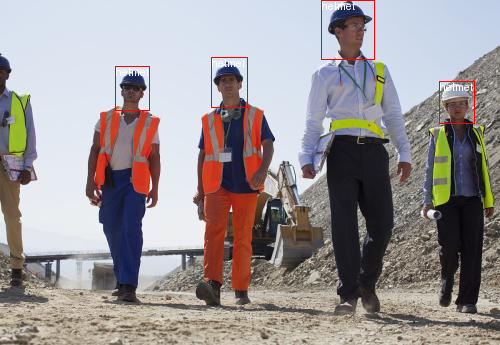

In [ ]:
draw_image_from_idx(dataset=train_dataset, idx=9)

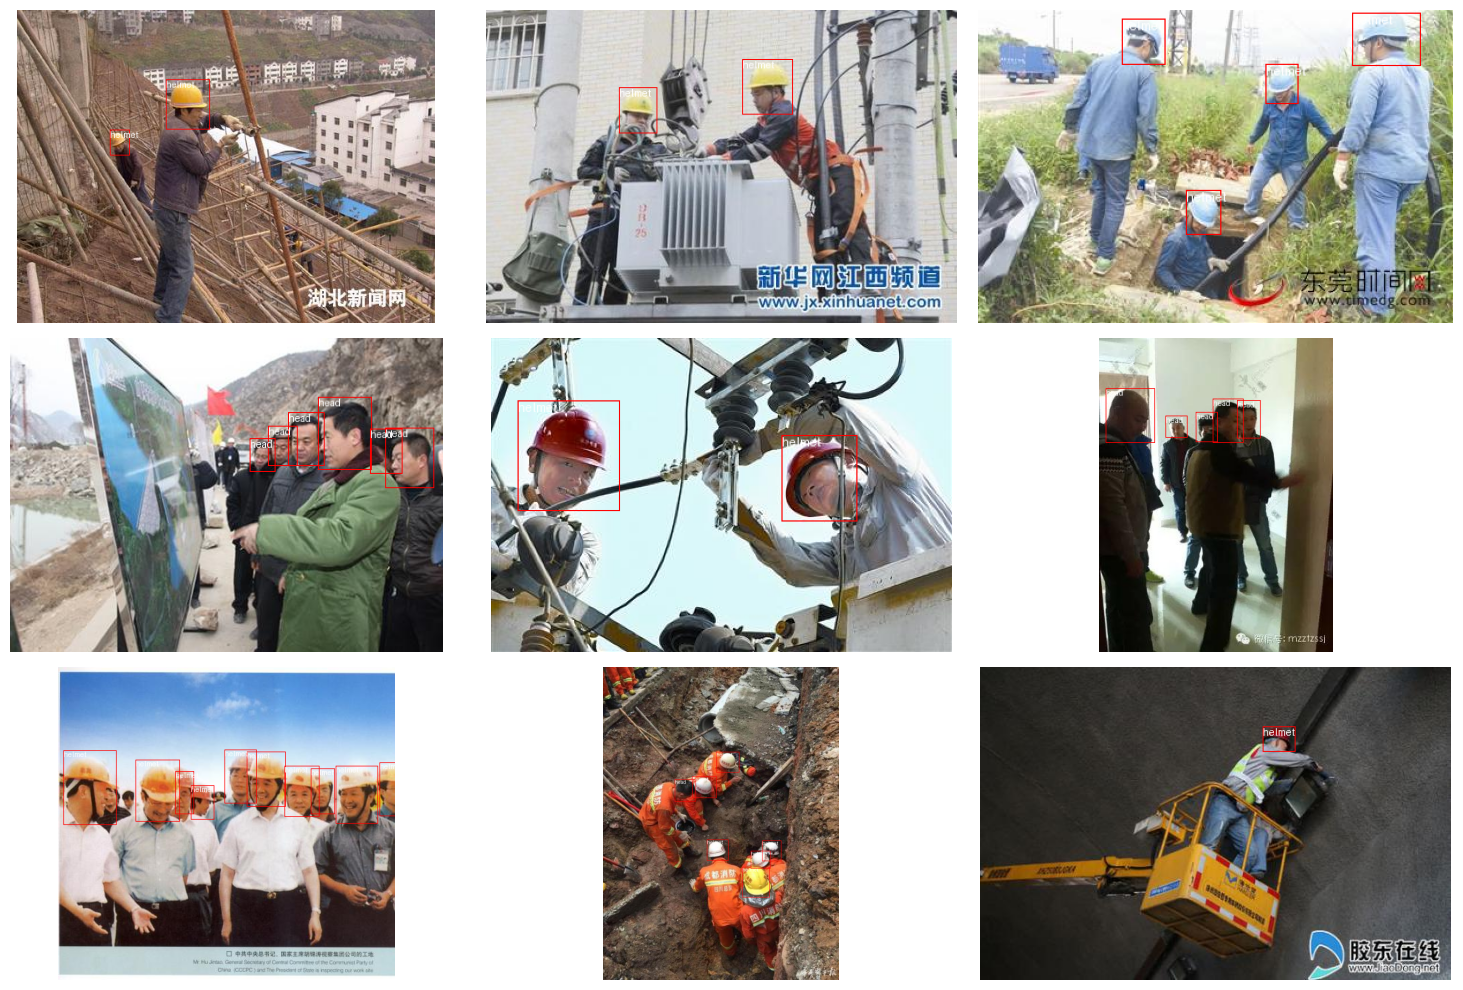

In [ ]:
# functions to plot multiple images

import matplotlib.pyplot as plt

def plot_images(dataset,indices):

  """
  plot images and their annotations
  """

  num_rows=len(indices)//3
  num_cols=3
  fig,axes= plt.subplots(num_rows, num_cols, figsize=(15,10))

  for i,idx in enumerate(indices):
    row=i//num_cols
    col=i%num_cols

    image=draw_image_from_idx(dataset,idx)

    axes[row,col].imshow(image)
    axes[row,col].axis("off")

  plt.tight_layout()
  plt.show()

plot_images(train_dataset,range(9))


In [ ]:
# autoimage procressor

from transformers import AutoImageProcessor

checkpoint="facebook/detr-resnet-50-dc5"
image_processor=AutoImageProcessor.from_pretrained(checkpoint)


preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

Augmentations are some set of random transformations like rotations, resizing etc which are applied to get more smaples and to make vision model more robust towards different conditions of the image.


In [ ]:
# preparing datasets

import albumentations
import numpy as np
import torch


transform=albumentations.Compose(
    [
        albumentations.Resize(480,480),
        albumentations.HorizontalFlip(p=1.0),
        albumentations.RandomBrightnessContrast(p=1.0),
    ],
    bbox_params=albumentations.BboxParams(format="coco",label_fields=["category"]),
)


```
Original image
      +
Original bounding boxes
      ↓
Albumentations
      ↓
Augmented image
      +
CORRESPONDING transformed bounding boxes
```

In [ ]:
def formatted_anns(image_id, category, area, bbox):
    annotations = []
    for i in range(0, len(category)):
        new_ann = {
            "image_id": image_id,
            "category_id": category[i],
            "isCrowd": 0,
            "area": area[i],
            "bbox": list(bbox[i]),
        }
        annotations.append(new_ann)

    return annotations

In [ ]:
def transform_aug_ann(examples):
  image_ids=examples["image_id"]
  images,bboxes,area,categories=[],[],[],[]

  for image,objects in zip(examples["image"],examples["objects"]):
    image = np.array(image.convert("RGB"))
    out=transform(image=image, bboxes=objects["bbox"], category=objects["id"])

    area.append(objects["area"])
    images.append(out["image"])
    bboxes.append(out["bboxes"])
    categories.append(out["category"])


  targets=[
      {"image_id":id_,"annotations":formatted_anns(id_,cat_,ar_,box_)}
      for id_, cat_, ar_, box_ in zip(image_ids,categories,area,bboxes)
  ]
  return image_processor(images=images, annotations=targets, return_tensors="pt")

In [ ]:
# Apply transformations for both train and test dataset

train_dataset_transformed = train_dataset.with_transform(transform_aug_ann)
test_dataset_transformed = test_dataset.with_transform(transform_aug_ann)



In [ ]:
train_dataset_transformed[0]

{'pixel_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]),
 'pixel_values': tensor([[[-0.0629, -0.0629, -0.0629,  ...,  0.5707,  0.3652,  0.2282],
          [-0.0629, -0.0629, -0.0629,  ...,  0.5536,  0.3481,  0.1939],
          [-0.0629, -0.0629, -0.0801,  ...,  0.5364,  0.3138,  0.1597],
          ...,
          [ 0.3309,  0.2111,  0.0398,  ..., -0.0801, -0.1486, -0.1999],
          [ 0.3309,  0.2111,  0.0227,  ..., -0.1143, -0.1828, -0.2342],
          [ 0.3309,  0.2111,  0.0227,  ..., -0.1314, -0.2171, -0.2684]],
 
         [[-0.0399, -0.0399, -0.0399,  ...,  0.1877, -0.0049, -0.1450],
          [-0.0399, -0.0399, -0.0399,  ...,  0.1702, -0.0399, -0.1800],
          [-0.0399, -0.0399, -0.0574,  ...,  0.1527, -0.0749, -0.2325],
          ...,
          [-0.0224, -0.1450, -0.3200,  ..., -0.4951, -0.5651, -

As a last preprocessing step,  we make custom collate_fn

`collate_fn`: It is responsible for taking a list of samples from dataset and converting them into a batch suitable for models input format.

Data Collator mainly puts the data together and then preprocesses them.

In [ ]:
def collate_fn(batch):
    pixel_values = torch.stack([
        item["pixel_values"].squeeze(0) for item in batch
    ])

    pixel_mask = torch.stack([
        item["pixel_mask"].squeeze(0) for item in batch
    ])

    labels = [item["labels"] for item in batch]

    return {
        "pixel_values": pixel_values,
        "pixel_mask": pixel_mask,
        "labels": labels,
    }


###  Training a DETR model

Training procedure includes following:

1. loading the base (pre-trained) model with AutoModelForObjectDetection using same checkpoints as in preprocessing

2. Defining all the hyperparameters and additional arguments inside training arguments

3. Pass the training_arguments inside HugginfFaceTrainer along with model, dataset and image

4. Call the train() method and fine tune model

In [ ]:
from transformers import AutoModelForObjectDetection

id2label={0:"head",1:"helmet",2:"person"}
label2id={v:k for k, v in id2label.items()}

model=AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

config.json:   0%|          | 0.00/4.38k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  167MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50-dc5
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |         

In [ ]:
from transformers import TrainingArguments
from transformers import Trainer

# Define the training arguments

training_args = TrainingArguments(
    output_dir="detr-resnet-50-hardhat-finetuned",
    per_device_train_batch_size=8,
    num_train_epochs=3,
    max_steps=1000,
    fp16=True,
    save_steps=10,
    logging_steps=30,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False,
)

# Define the trainer

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    train_dataset=train_dataset_transformed,
    eval_dataset=test_dataset_transformed,
    processing_class=image_processor
)

trainer.train()

Step,Training Loss
30,3.509200
60,2.433466
90,1.985777
120,1.797164
150,1.683341
180,1.571614
210,1.464353
240,1.417852
270,1.404028
300,1.319496


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=1.3582348194122313, metrics={'train_runtime': 2017.9318, 'train_samples_per_second': 3.964, 'train_steps_per_second': 0.496, 'total_flos': 3.81913436316672e+18, 'train_loss': 1.3582348194122313, 'epoch': 1.5082956259426847})

> "Take my DETR model, show it my hard-hat images 1,000 times/batches, compare its predictions with the correct bounding boxes, adjust its internal parameters, and save the improved model."



In [ ]:
# testing and inference

import requests
from transformers import pipeline

url = "https://huggingface.co/datasets/hf-vision/course-assets/resolve/main/test-helmet-object-detection.jpg"
image=Image.open(requests.get(url,stream=True).raw)

obj_detector=pipeline(
    "object-detection", model="anindya64/detr-resnet-50-dc5-hardhat-finetuned"
)

results=obj_detector(train_dataset[0]["image"])
print(results)

config.json:   0%|          | 0.00/1.32k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  166MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

[{'score': 0.9988483190536499, 'label': 'helmet', 'box': {'xmin': 108, 'ymin': 145, 'xmax': 131, 'ymax': 174}}, {'score': 0.9999990463256836, 'label': 'helmet', 'box': {'xmin': 179, 'ymin': 83, 'xmax': 232, 'ymax': 144}}]


In [ ]:
trainer.save_model("detr-resnet-50-hardhat-finetuned")
image_processor.save_pretrained("detr-resnet-50-hardhat-finetuned")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['detr-resnet-50-hardhat-finetuned/preprocessor_config.json']

In [ ]:
import shutil

shutil.make_archive(
    "detr-resnet-50-hardhat-finetuned",
    "zip",
    "detr-resnet-50-hardhat-finetuned"
)


'/content/detr-resnet-50-hardhat-finetuned.zip'

In [ ]:
def plot_results(image,results,threshold=0.7):
  image=Image.fromarray(np.uint8(image))
  draw=ImageDraw.Draw(image)

  for result in results:
    score=result["score"]
    label=result["label"]
    box=list(result["box"].values())

    if score>threshold:
      x,y,x2,y2 =tuple(box)
      draw.rectangle((x,y,x2,y2),outline="red",width=1)
      draw.text((x,y),label,fill="white")

      draw.text(
          (x+0.5,y-0.5),
          text=str(score),
          fill="green" if score >0.7 else "red",
      )

    return image

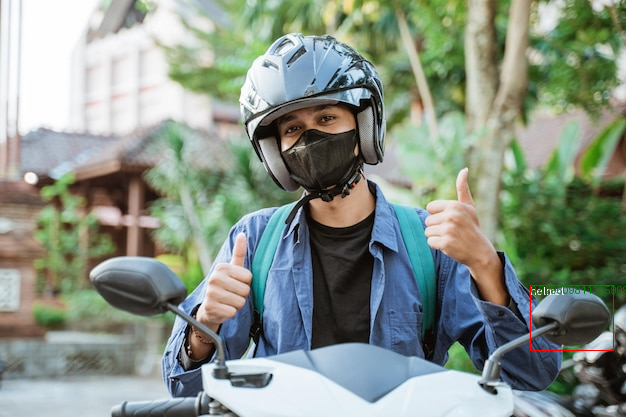

In [ ]:
# use function for same test

results=obj_detector(image)
plot_results(image,results)

In [ ]:
def predict(image, pipeline, threshold=0.7):
    results = pipeline(image)
    return results

In [ ]:
img=test_dataset[0]["image"]
predict(img,obj_detector)
print(type(results))

<class 'list'>


In [ ]:
from tqdm.auto import tqdm

In [ ]:
def predict(image, pipeline, threshold=0.7):
    results = pipeline(image)
    return results

100%|██████████| 6/6 [00:01<00:00,  4.36it/s]


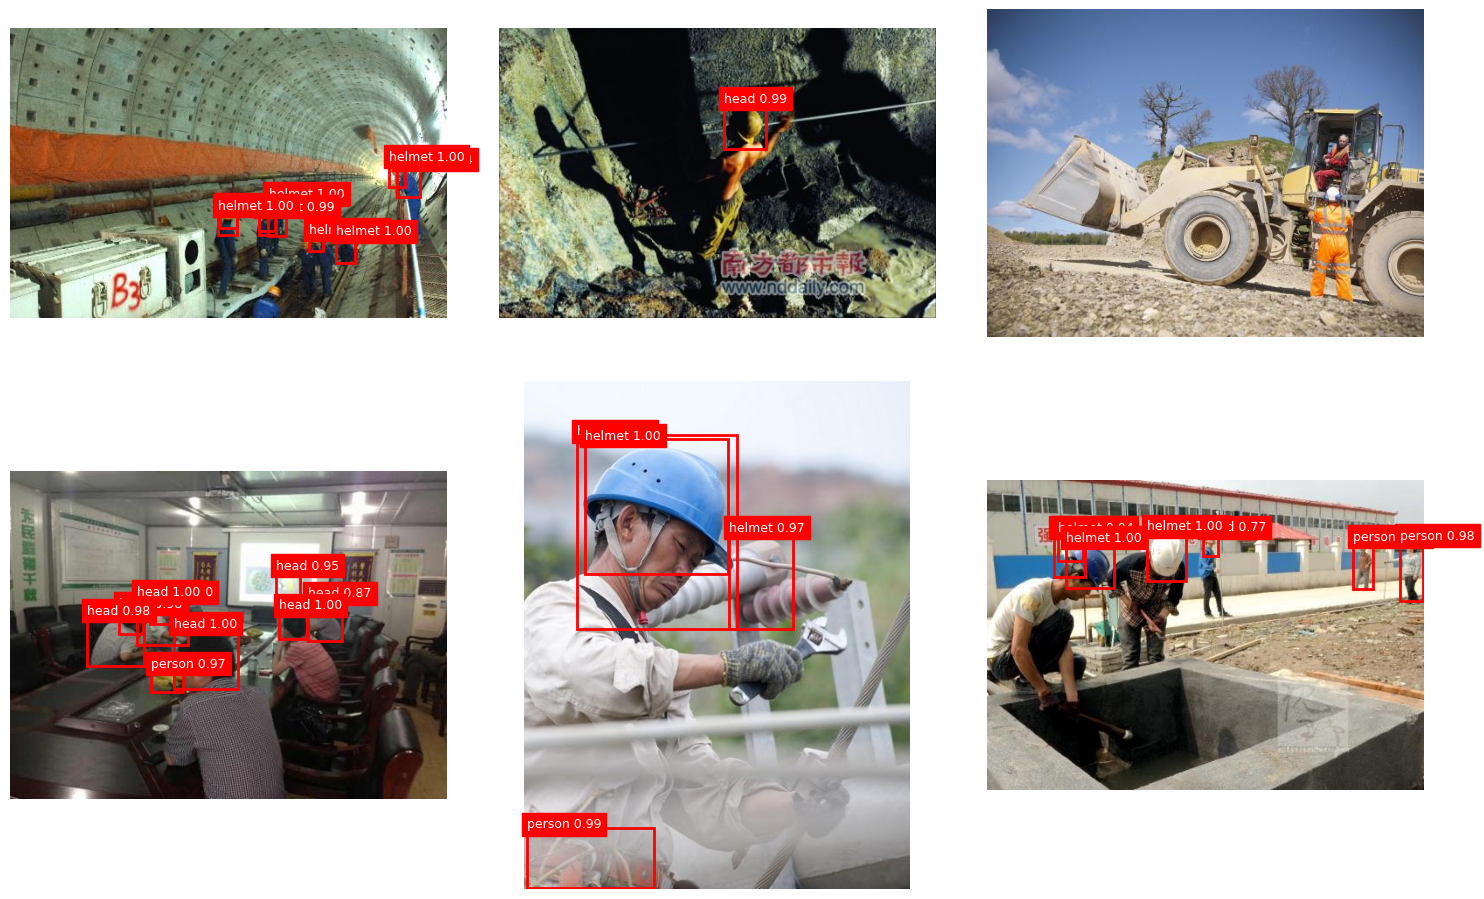

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

def plot_images(dataset, indices, threshold=0.7):

    num_cols = 3
    num_rows = (len(indices) + num_cols - 1) // num_cols

    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(15, 5 * num_rows)
    )

    axes = np.array(axes).reshape(-1)

    for i, idx in tqdm(enumerate(indices), total=len(indices)):

        # Original image
        image = dataset[idx]["image"].convert("RGB")

        # Run detector
        results = obj_detector(image)

        # Draw original image
        axes[i].imshow(image)

        # Draw predictions
        for result in results:

            if result["score"] < threshold:
                continue

            box = result["box"]

            xmin = box["xmin"]
            ymin = box["ymin"]
            xmax = box["xmax"]
            ymax = box["ymax"]

            # Rectangle
            rect = plt.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                fill=False,
                color="red",
                linewidth=2
            )

            axes[i].add_patch(rect)

            # Label
            axes[i].text(
                xmin,
                ymin,
                f'{result["label"]} {result["score"]:.2f}',
                color="white",
                backgroundcolor="red",
                fontsize=9
            )

        axes[i].axis("off")

    # Hide unused subplots
    for i in range(len(indices), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

plot_images(test_dataset, range(6))

